# ECG Arrhythmia Detection with Machine Learning

### Statistical Analysis, Dimensionality Reduction and Classification of ECG Heartbeats

This project explores the detection of cardiac arrhythmias from electrocardiogram (ECG) signals using statistical analysis and machine learning techniques.

The analysis is based on the **ECG Heartbeat Categorization Dataset**, derived from the MIT-BIH Arrhythmia Database. Each heartbeat is represented by 187 ECG signal measurements and classified into one of five heartbeat categories.

The project covers the complete analytical pipeline:

- Exploratory Data Analysis (EDA)
- Statistical analysis of ECG signals
- Dimensionality reduction using PCA
- Binary and multiclass heartbeat classification
- Logistic Regression and Decision Tree models
- Model evaluation using Precision, Recall and F1-score
- Conditional probability analysis using Bayes' theorem

The main objective is not only to obtain accurate predictions, but also to understand the statistical characteristics of ECG signals and evaluate the trade-off between detecting abnormal heartbeats and generating false positives.

## 1. Exploratory Data Analysis

The first stage focuses on understanding the structure and characteristics of the ECG dataset before training any predictive models.

Special attention is given to **class imbalance**, since normal heartbeats represent the majority of the observations. This makes accuracy alone an insufficient metric for evaluating the subsequent classification models.

The analysis includes:

- Class distribution
- Descriptive statistics of ECG amplitudes
- Statistical features aggregated by heartbeat
- Representative ECG signals for each class
- Average heartbeat morphology by class

### 1.1 Dataset Loading

The training and test datasets are loaded separately to preserve a correct evaluation workflow. Each row represents a single heartbeat composed of 187 ECG signal measurements and one class label.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga
df = pd.read_csv("mitbih_train.csv", header=None)

# Convertir a numérico y separar X/y
df = df.apply(pd.to_numeric, errors="coerce").dropna()
X = df.iloc[:, :-1]
y = df.iloc[:, -1].astype(int) #Etiqueta con 5 clases para EDA, PCA y Bayes
y_bin = (y != 0).astype(int) #Etiqueta binaria para latidos (0=normal, 1=anómalo) para modelos

print("Shape:", df.shape)
print("Clases:", y.value_counts().sort_index())
print(y_bin.value_counts())

### 1.2 Class Distribution

The target variable is highly imbalanced, with normal heartbeats representing the majority of the dataset. This imbalance must be considered when interpreting model performance, since accuracy alone may provide an overly optimistic view of the results.

In [ ]:
# Distribución de clases
class_counts = y.value_counts().sort_index()
class_pct = (class_counts / len(y) * 100).round(2)
print("\nDistribución de clases:\n", pd.DataFrame({"count": class_counts, "%": class_pct}))

plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Distribución de clases (train)")
plt.xlabel("Clase")
plt.ylabel("Nº latidos")
plt.show()

### 1.3 ECG Signal Statistics

Descriptive statistics are used to characterize the global distribution of ECG amplitudes and identify patterns in signal variability.

In [ ]:
# Estadística descriptiva global (sobre amplitudes del ECG)
# Aplanamos todas las muestras para describir la amplitud global
vals = X.to_numpy().ravel()

def basic_stats(a):
    a = np.asarray(a)
    return {
        "n": a.size,
        "min": float(np.min(a)),
        "p25": float(np.percentile(a, 25)),
        "median": float(np.median(a)),
        "mean": float(np.mean(a)),
        "p75": float(np.percentile(a, 75)),
        "max": float(np.max(a)),
        "var": float(np.var(a, ddof=1)),
        "std": float(np.std(a, ddof=1)),
        "range": float(np.max(a) - np.min(a)),
    }

print("\nStats amplitud global:\n", basic_stats(vals))

# Histograma de amplitud global
plt.figure()
plt.hist(vals, bins=60)
plt.title("Histograma de amplitud (todas las muestras)")
plt.xlabel("Amplitud normalizada")
plt.ylabel("Frecuencia")
plt.show()

### 1.4 Statistical Features by Heartbeat

To summarize the morphology of each heartbeat, several statistical features are extracted from the 187 signal measurements, including mean, standard deviation, minimum, maximum and peak-to-peak range.

In [ ]:
# Estadística por latido (features agregadas por fila)
# Esto ayuda a comparar clases sin comerte 187 stats por columna
row_stats = pd.DataFrame({
    "mean": X.mean(axis=1),
    "std": X.std(axis=1),
    "ptp": (X.max(axis=1) - X.min(axis=1)),
    "class": y.values
})
row_stats["class"] = y.values

print("\nResumen por latido (global):\n", row_stats.drop(columns="class").describe().round(4))

# Boxplots por clase (de mean y std)
plt.figure()
plt.boxplot([row_stats.loc[row_stats["class"]==c, "mean"].values for c in sorted(y.unique())],
            labels=[str(c) for c in sorted(y.unique())])
plt.title("Boxplot de la media por latido, por clase")
plt.xlabel("Clase")
plt.ylabel("Media amplitud")
plt.show()

plt.figure()
plt.boxplot([row_stats.loc[row_stats["class"]==c, "std"].values for c in sorted(y.unique())],
            labels=[str(c) for c in sorted(y.unique())])
plt.title("Boxplot de la desviación típica por latido, por clase")
plt.xlabel("Clase")
plt.ylabel("Std amplitud")
plt.show()

### 1.5 Representative ECG Signals

Individual and average ECG signals are visualized for each class to identify morphological differences between normal and abnormal heartbeats.

Shape: (87554, 188)
Clases: 187
0    72471
1     2223
2     5788
3      641
4     6431
Name: count, dtype: int64
187
0    72471
1    15083
Name: count, dtype: int64

Distribución de clases:
      count      %
187              
0    72471  82.77
1     2223   2.54
2     5788   6.61
3      641   0.73
4     6431   7.35


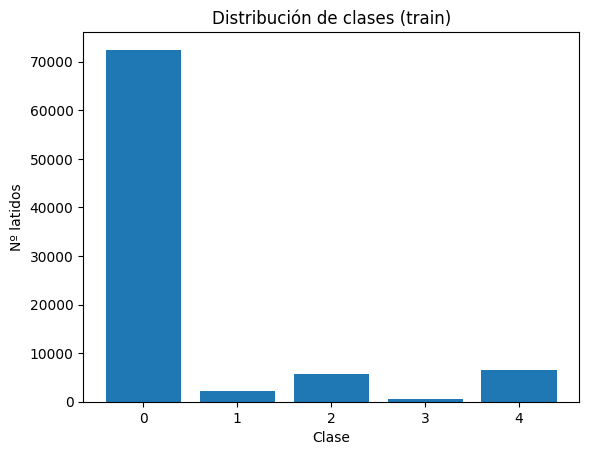


Stats amplitud global:
 {'n': 16372598, 'min': 0.0, 'p25': 0.0, 'median': 0.08296943455934525, 'mean': 0.17428295254906373, 'p75': 0.28915661573410034, 'max': 1.0, 'var': 0.05122408932113581, 'std': 0.22632739410229558, 'range': 1.0}


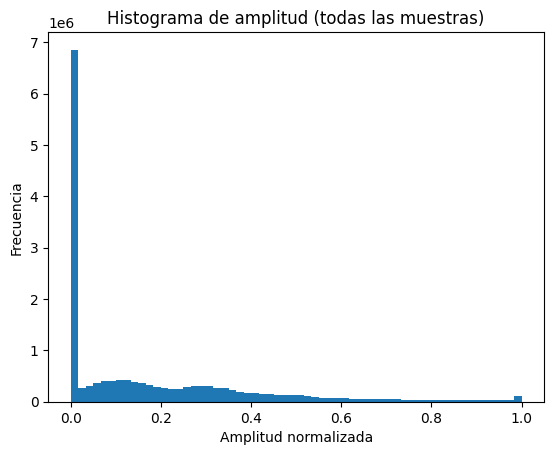


Resumen por latido (global):
              mean         std         ptp
count  87554.0000  87554.0000  87554.0000
mean       0.1743      0.1935      0.9997
std        0.1056      0.0533      0.0075
min        0.0129      0.0684      0.6143
25%        0.0980      0.1579      1.0000
50%        0.1451      0.1808      1.0000
75%        0.2179      0.2144      1.0000
max        0.7620      0.4859      1.0000


/tmp/ipython-input-330998479.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([row_stats.loc[row_stats["class"]==c, "mean"].values for c in sorted(y.unique())],


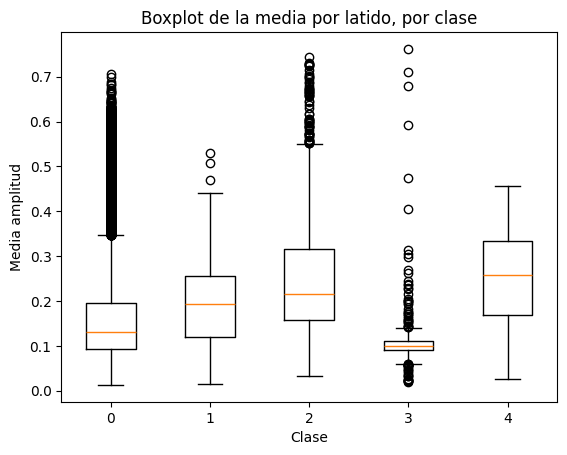

/tmp/ipython-input-330998479.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([row_stats.loc[row_stats["class"]==c, "std"].values for c in sorted(y.unique())],


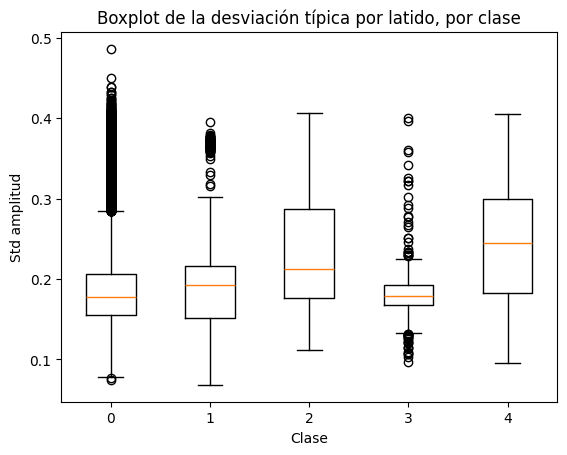

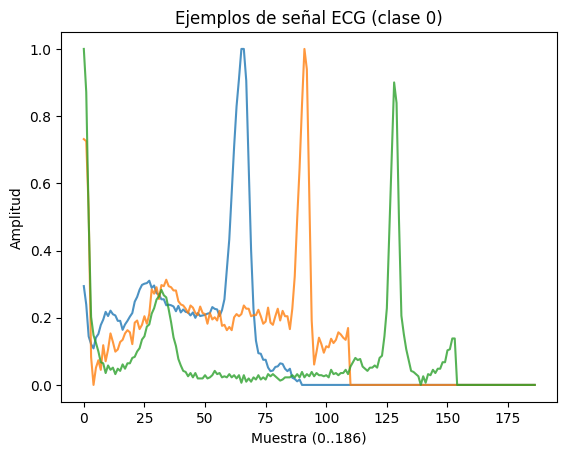

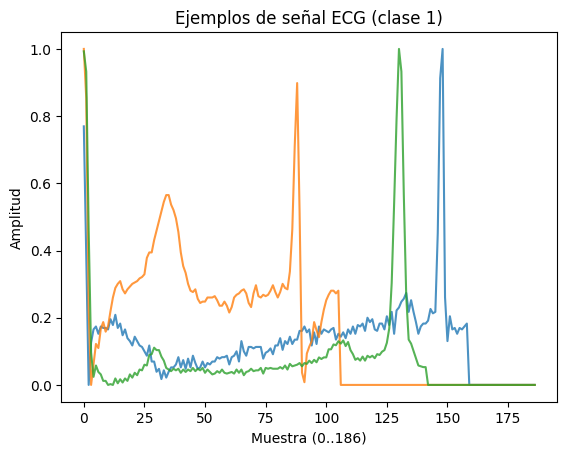

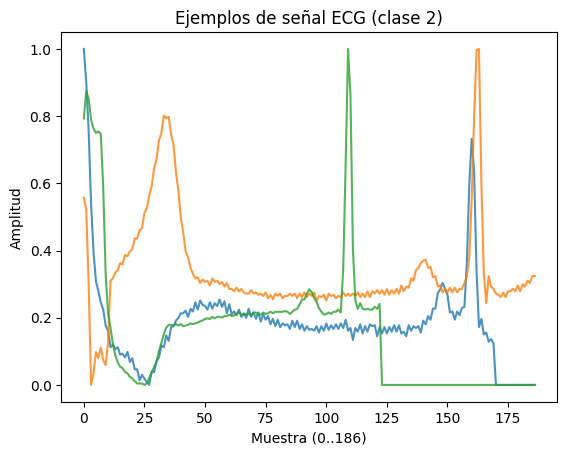

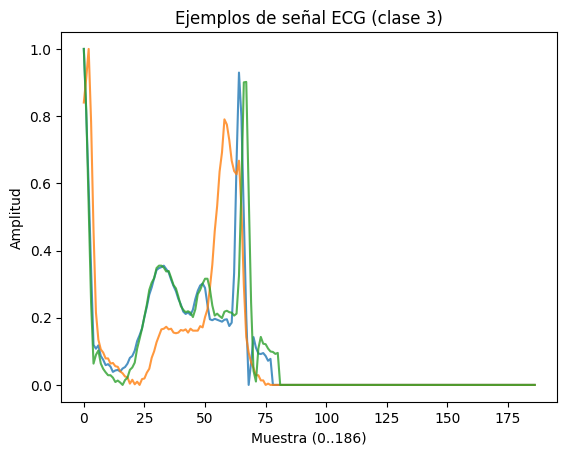

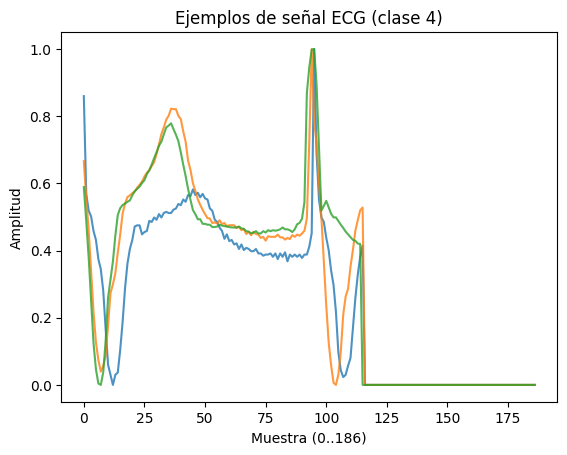

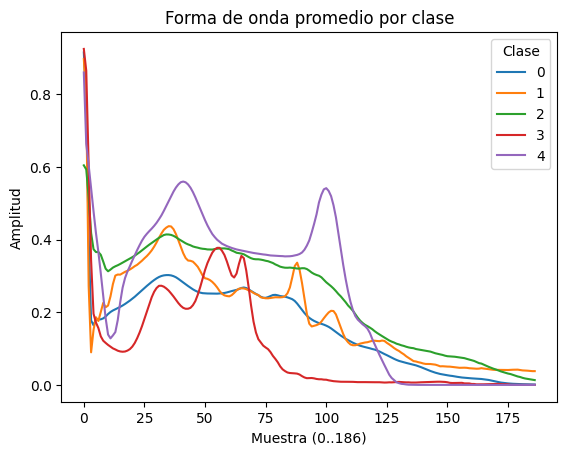

In [ ]:
# Señales típicas por clase
# Dibujamos algunas ondas aleatorias por clase
rng = np.random.default_rng(42)

for c in sorted(y.unique()):
    idx = np.where(y.values == c)[0]
    pick = rng.choice(idx, size=min(3, len(idx)), replace=False)

    plt.figure()
    for i in pick:
        plt.plot(X.iloc[i].values, alpha=0.8)
    plt.title(f"Ejemplos de señal ECG (clase {c})")
    plt.xlabel("Muestra (0..186)")
    plt.ylabel("Amplitud")
    plt.show()

# Señal "promedio" por clase
plt.figure()
for c in sorted(y.unique()):
    mean_wave = X[y==c].mean(axis=0).values
    plt.plot(mean_wave, label=str(c))
plt.title("Forma de onda promedio por clase")
plt.xlabel("Muestra (0..186)")
plt.ylabel("Amplitud")
plt.legend(title="Clase")
plt.show()


## 2. Dimensionality Reduction with PCA

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the ECG signals while preserving as much variance as possible.

Since each heartbeat is represented by 187 signal measurements, PCA helps identify dominant patterns in the data and enables a two-dimensional visualization of the class structure.

### 2.1 Feature Standardization

The ECG features are standardized before applying PCA so that all signal measurements contribute on a comparable scale.

The scaler is fitted exclusively on the training set to avoid data leakage.

In [ ]:
#2: PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estandarizar (IMPORTANTE para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2.2 Principal Component Analysis

PCA is fitted on the standardized training data to identify the directions that explain the greatest amount of variance in the ECG signals.

In [ ]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### 2.3 Explained Variance

The cumulative explained variance is analyzed to determine how much information is retained as the number of principal components increases.

The first two components explain approximately **52.26% of the total variance**, which is sufficient for exploratory visualization but not for fully representing the original feature space.

In [ ]:
# Varianza explicada
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

print("Varianza explicada PC1:", round(explained_var[0], 4))
print("Varianza explicada PC2:", round(explained_var[1], 4))
print("Varianza acumulada PC1+PC2:", round(cum_var[1], 4))

### 2.4 PCA Projection

The ECG samples are projected onto the first two principal components to explore whether the heartbeat classes form clearly separable regions.

The visualization shows partial structure, but substantial overlap remains between the different abnormal heartbeat classes.

Varianza explicada PC1: 0.3663
Varianza explicada PC2: 0.1563
Varianza acumulada PC1+PC2: 0.5226


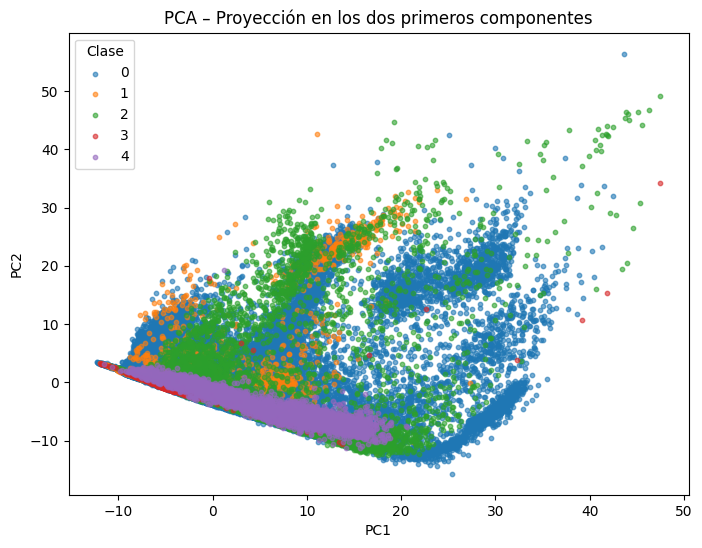

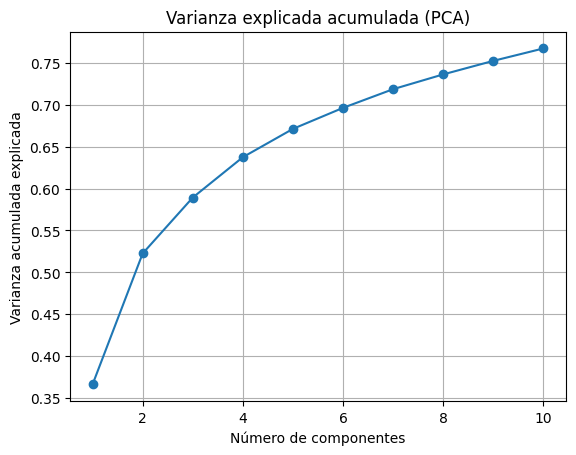

In [ ]:
#SCATTER PLOT PC1 Y PC2 POR CLASE

plt.figure(figsize=(8,6))

for c in sorted(y.unique()):
    plt.scatter(
        X_pca[y==c, 0],
        X_pca[y==c, 1],
        s=10,
        alpha=0.6,
        label=str(c)
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA – Proyección en los dos primeros componentes")
plt.legend(title="Clase")
plt.show()

#VARIANZA EXPLICADA ACUMULADA

plt.figure()
plt.plot(range(1, 11), cum_var[:10], marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza explicada acumulada (PCA)")
plt.grid(True)
plt.show()

### 2.5 Interpretation

PCA reveals that ECG signals contain strong correlations and dominant patterns, since a relatively small number of components captures a significant proportion of the total variance.

However, the considerable overlap between classes indicates that PCA should be treated primarily as an exploratory and dimensionality-reduction technique rather than as a standalone classification method.

## 3. Supervised Classification

Two supervised learning models are evaluated to classify ECG heartbeats:

- Logistic Regression
- Decision Tree

The goal is to compare a linear baseline with a non-linear model and assess their ability to handle the strong class imbalance present in the dataset.

Model performance is evaluated using confusion matrices, precision, recall and F1-score, with particular attention to minority and abnormal heartbeat classes.

### 3.1 Logistic Regression

Logistic Regression is used as a linear baseline model.

Because the ECG classes exhibit substantial overlap and the decision boundaries are expected to be non-linear, this model provides a useful reference point for evaluating more flexible classifiers.

In [ ]:
#MODELOS DE CLASIFICACIÓN

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

X_train, X_val, y_train, y_val = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

### 3.1 Logistic Regression

Logistic Regression is used as a linear baseline model.

Because the ECG classes exhibit substantial overlap and the decision boundaries are expected to be non-linear, this model provides a useful reference point for evaluating more flexible classifiers.

In [ ]:
#MODELO 1: REGRESIÓN LOGÍSTICA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

#### Logistic Regression Evaluation

The model is evaluated using both global and class-level metrics.

Given the dataset imbalance, macro-averaged metrics and recall for abnormal classes are particularly relevant, since high overall accuracy may hide poor performance on minority classes.

In [ ]:
logreg.fit(X_train_s, y_train)
y_pred_lr = logreg.predict(X_val_s)

print("Regresión logística (binaria)")
print(confusion_matrix(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr, digits=3))

### 3.2 Decision Tree

A Decision Tree classifier is trained to capture non-linear relationships between ECG signal features.

Unlike Logistic Regression, decision trees can model complex interactions and non-linear decision boundaries without requiring an explicit transformation of the original feature space.

In [ ]:
#MODELO 2: ÁRBOLES DE DECISIÓN
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

#### Decision Tree Evaluation

The same evaluation metrics are used to ensure a fair comparison between models.

Particular attention is paid to recall and F1-score across classes, since the main objective is not only to identify normal heartbeats but also to correctly detect abnormal patterns.

In [ ]:
tree.fit(X_train, y_train)
y_pred_dt = tree.predict(X_val)

print("Árbol de decisión (binario)")
print(confusion_matrix(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt, digits=3))

### 3.3 Model Comparison

The Decision Tree clearly outperforms Logistic Regression on this dataset.

In the multiclass setting, the Decision Tree achieves approximately:

- **Accuracy:** 88.9%
- **Macro Recall:** 0.85
- **Macro F1-score:** 0.68

This improvement suggests that the ECG classification problem contains non-linear relationships that cannot be adequately captured by a purely linear model.

In [ ]:
#RESUMEN MODELOS
from sklearn.metrics import f1_score, precision_score, recall_score

results_bin = pd.DataFrame({
    "Modelo": ["Regresión logística", "Árbol de decisión"],
    "F1": [
        f1_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_val, y_pred_lr),
        recall_score(y_val, y_pred_dt)
    ]
})

print(results_bin)

Regresión logística (binaria)
[[12509  1985]
 [  624  2393]]
              precision    recall  f1-score   support

           0      0.952     0.863     0.906     14494
           1      0.547     0.793     0.647      3017

    accuracy                          0.851     17511
   macro avg      0.750     0.828     0.776     17511
weighted avg      0.883     0.851     0.861     17511

Árbol de decisión (binario)
[[13792   702]
 [  301  2716]]
              precision    recall  f1-score   support

           0      0.979     0.952     0.965     14494
           1      0.795     0.900     0.844      3017

    accuracy                          0.943     17511
   macro avg      0.887     0.926     0.905     17511
weighted avg      0.947     0.943     0.944     17511

                Modelo        F1    Recall
0  Regresión logística  0.647194  0.793172
1    Árbol de decisión  0.844134  0.900232


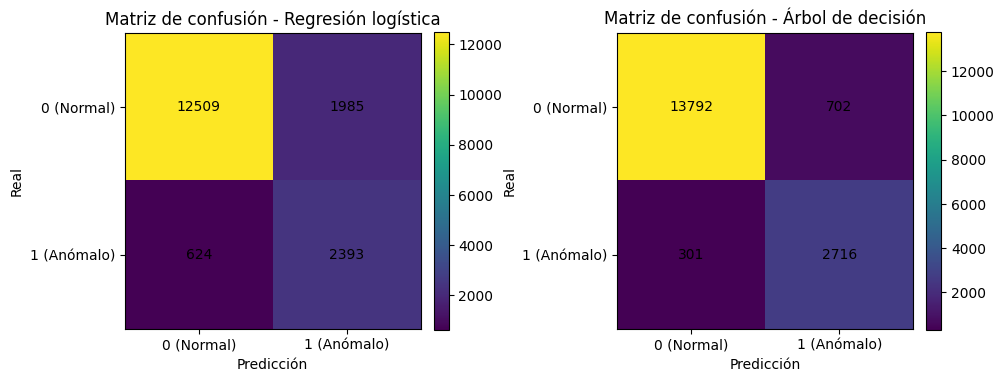

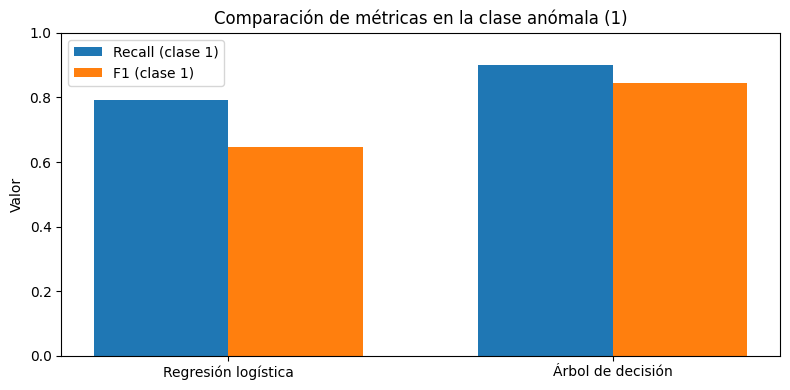

In [ ]:
# Matrices de confusión
cm_lr = np.array([[12509, 1985],
                  [  624, 2393]])

cm_dt = np.array([[13792,  702],
                  [  301, 2716]])

def plot_confusion_matrix(ax, cm, title):
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], labels=["0 (Normal)", "1 (Anómalo)"])
    ax.set_yticks([0, 1], labels=["0 (Normal)", "1 (Anómalo)"])

    # números dentro
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Dos matrices lado a lado (una figura)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(axes[0], cm_lr, "Matriz de confusión - Regresión logística")
plot_confusion_matrix(axes[1], cm_dt, "Matriz de confusión - Árbol de decisión")
plt.tight_layout()
plt.show()


#2) Bar plot comparativo (Recall y F1 de la clase 1)
models = ["Regresión logística", "Árbol de decisión"]
recall_c1 = [0.793172, 0.900232]
f1_c1 = [0.647194, 0.844134]

x = np.arange(len(models))
w = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - w/2, recall_c1, width=w, label="Recall (clase 1)")
plt.bar(x + w/2, f1_c1, width=w, label="F1 (clase 1)")
plt.xticks(x, models, rotation=0)
plt.ylim(0, 1.0)
plt.title("Comparación de métricas en la clase anómala (1)")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Conditional Probability and Bayesian Analysis

Bayes' theorem is used to analyze how specific ECG signal patterns modify the probability that a heartbeat belongs to a pathological class.

The analysis focuses on distinguishing **normal heartbeats (class 0)** from **ventricular heartbeats (class 2)** using simple statistical patterns extracted from the ECG signal.

Three candidate patterns are evaluated:

- Maximum signal amplitude
- Heartbeat energy
- Maximum signal slope

### 4.1 Maximum Amplitude

The first pattern considers whether the maximum ECG amplitude exceeds the 90th percentile of its global distribution.

Bayes' theorem is then applied to estimate how observing this pattern modifies the posterior probability of a ventricular heartbeat.

The posterior probability of a ventricular heartbeat remains almost unchanged from its prior probability (~7.4%).

Therefore, maximum amplitude alone provides very little discriminatory information between normal and ventricular heartbeats.

### 4.2 Heartbeat Energy

The second pattern uses the total energy of the ECG signal, calculated as the sum of squared amplitudes.

A heartbeat is considered to exhibit the pattern when its energy exceeds the 90th percentile of the global energy distribution.

Unlike maximum amplitude, heartbeat energy provides meaningful discriminatory information.

When a high-energy pattern is observed, the posterior probability of a ventricular heartbeat increases from approximately **7.4% to 22.9%**.

This suggests that heartbeat energy captures relevant morphological information associated with ventricular beats.

### 4.3 Maximum Signal Slope

The final pattern analyzes the maximum absolute slope of the ECG signal as an approximation of how rapidly its amplitude changes.

As in the previous experiments, the 90th percentile is used to define the presence of the pattern.

In this case, observing the pattern reduces the posterior probability of a ventricular heartbeat to approximately **2.6%**.

Therefore, this particular definition of maximum slope does not provide a useful indicator for detecting ventricular heartbeats.

In [ ]:
#PASO 4: PROBABILIDAD COMDICIONADA Y TEOREMA DE BAYES

import numpy as np
import pandas as pd

# Filtrar solo clases 0 y 2
mask = y.isin([0, 2])
X02 = X[mask]
y02 = y[mask]

# Definir patrón X: max(signal) >= tau (tau = percentil 90 en 0 y 2)
max_per_beat = X02.max(axis=1).values
tau = np.quantile(max_per_beat, 0.90)

X_event = max_per_beat >= tau  # presencia de patrón X (boolean)

# Probabilidades marginales
P_C2 = np.mean(y02.values == 2)
P_C0 = np.mean(y02.values == 0)

# Condicionales: P(X|C)
P_X_given_C2 = np.mean(X_event[y02.values == 2])
P_X_given_C0 = np.mean(X_event[y02.values == 0])

# Marginal del evento: P(X)
P_X = np.mean(X_event)

# Bayes: P(C|X) = P(X|C)P(C)/P(X)
P_C2_given_X = (P_X_given_C2 * P_C2) / P_X
P_C0_given_X = (P_X_given_C0 * P_C0) / P_X

print(f"tau (p90 del max): {tau:.4f}")
print(f"P(C2)={P_C2:.4f}  P(C0)={P_C0:.4f}")
print(f"P(X|C2)={P_X_given_C2:.4f}  P(X|C0)={P_X_given_C0:.4f}")
print(f"P(X)={P_X:.4f}")
print(f"P(C2|X)={P_C2_given_X:.4f}  P(C0|X)={P_C0_given_X:.4f}")


#PATRON X = ENERGÍA ALTA
import numpy as np

# Solo clases 0 y 2
mask = y.isin([0, 2])
X02 = X[mask]
y02 = y[mask]

# Energía por latido
E = (X02.values ** 2).sum(axis=1)

# Umbral: percentil 90 de la energía (en el conjunto 0+2)
tau = np.quantile(E, 0.90)
X_event = E >= tau

# Marginales
P_C2 = np.mean(y02.values == 2)
P_C0 = np.mean(y02.values == 0)

# Condicionales
P_X_given_C2 = np.mean(X_event[y02.values == 2])
P_X_given_C0 = np.mean(X_event[y02.values == 0])

# P(X)
P_X = np.mean(X_event)

# Bayes
P_C2_given_X = (P_X_given_C2 * P_C2) / P_X
P_C0_given_X = (P_X_given_C0 * P_C0) / P_X

print(f"[ENERGÍA] tau(p90)={tau:.4f}")
print(f"P(C2)={P_C2:.4f}  P(C0)={P_C0:.4f}")
print(f"P(X|C2)={P_X_given_C2:.4f}  P(X|C0)={P_X_given_C0:.4f}")
print(f"P(X)={P_X:.4f}")
print(f"P(C2|X)={P_C2_given_X:.4f}  P(C0|X)={P_C0_given_X:.4f}")


#PATRON X = PENDIENTE MÁXIMA ALTA
import numpy as np

mask = y.isin([0, 2])
X02 = X[mask]
y02 = y[mask]

# Pendiente máxima (diferencias absolutas)
S = np.abs(np.diff(X02.values, axis=1)).max(axis=1)

tau = np.quantile(S, 0.90)
X_event = S >= tau

P_C2 = np.mean(y02.values == 2)
P_C0 = np.mean(y02.values == 0)

P_X_given_C2 = np.mean(X_event[y02.values == 2])
P_X_given_C0 = np.mean(X_event[y02.values == 0])

P_X = np.mean(X_event)

P_C2_given_X = (P_X_given_C2 * P_C2) / P_X
P_C0_given_X = (P_X_given_C0 * P_C0) / P_X

print(f"[PENDIENTE] tau(p90)={tau:.4f}")
print(f"P(C2)={P_C2:.4f}  P(C0)={P_C0:.4f}")
print(f"P(X|C2)={P_X_given_C2:.4f}  P(X|C0)={P_X_given_C0:.4f}")
print(f"P(X)={P_X:.4f}")
print(f"P(C2|X)={P_C2_given_X:.4f}  P(C0|X)={P_C0_given_X:.4f}")



tau (p90 del max): 1.0000
P(C2)=0.0740  P(C0)=0.9260
P(X|C2)=0.9979  P(X|C0)=0.9996
P(X)=0.9995
P(C2|X)=0.0738  P(C0|X)=0.9262
[ENERGÍA] tau(p90)=27.8038
P(C2)=0.0740  P(C0)=0.9260
P(X|C2)=0.3100  P(X|C0)=0.0832
P(X)=0.1000
P(C2|X)=0.2292  P(C0|X)=0.7708
[PENDIENTE] tau(p90)=0.6878
P(C2)=0.0740  P(C0)=0.9260
P(X|C2)=0.0356  P(X|C0)=0.1051
P(X)=0.1000
P(C2|X)=0.0263  P(C0|X)=0.9737


In [ ]:
#Evaluación final sobre TEST
df_test = pd.read_csv("mitbih_test.csv", header=None)
df_test = df_test.apply(pd.to_numeric, errors="coerce").dropna()

X_test_final = df_test.iloc[:, :-1]
y_test_final = df_test.iloc[:, -1].astype(int)

# Escalado con scaler entrenado SOLO en TRAIN
X_test_final_s = scaler.transform(X_test_final)

# Predicción con el mejor modelo (árbol de decisión)
y_test_pred = tree.predict(X_test_final)

print(confusion_matrix(y_test_final, y_test_pred))
print(classification_report(y_test_final, y_test_pred, digits=3))

[[17230   888     0     0     0]
 [  191   365     0     0     0]
 [  100  1348     0     0     0]
 [   51   111     0     0     0]
 [   37  1571     0     0     0]]
              precision    recall  f1-score   support

           0      0.978     0.951     0.965     18118
           1      0.085     0.656     0.151       556
           2      0.000     0.000     0.000      1448
           3      0.000     0.000     0.000       162
           4      0.000     0.000     0.000      1608

    accuracy                          0.804     21892
   macro avg      0.213     0.321     0.223     21892
weighted avg      0.812     0.804     0.802     21892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5. Conclusions

This project demonstrates a complete statistical and machine learning workflow for ECG heartbeat analysis.

The exploratory analysis revealed a strongly imbalanced dataset and substantial morphological overlap between heartbeat classes, highlighting the limitations of relying exclusively on global accuracy.

PCA showed that the first two principal components capture approximately **52.3% of the total variance**, revealing underlying structure in the ECG signals while also showing considerable overlap between classes.

Among the evaluated classifiers, the **Decision Tree consistently outperformed Logistic Regression**, particularly when detecting abnormal heartbeats. In the binary classification setting, the Decision Tree achieved approximately **94.3% accuracy, 90.0% recall and an F1-score of 84.4% for abnormal heartbeats**.

The Bayesian analysis further showed that simple statistical properties of ECG signals differ considerably in their predictive value. In particular, high heartbeat energy increased the estimated probability of a ventricular heartbeat from approximately **7.4% to 22.9%**, whereas maximum amplitude provided almost no additional information.

Overall, the results highlight the importance of combining statistical analysis, dimensionality reduction, appropriate evaluation metrics and non-linear machine learning models when working with imbalanced biomedical signal data.